<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Hcktn_R_(rf_lg).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & IMPORT LIBRARIES
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("🔑 Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')


🔑 Step 1: Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Define Base Path for Google Drive Data

This cell explicitly defines the `DRIVE_HACKATHON_BASE_PATH` to ensure all subsequent data loading and saving operations correctly locate files within your Google Drive. This helps prevent `NameError` issues.

In [ ]:
# Import Path for robust path handling
from pathlib import Path

# Define the base path for your hackathon data in Google Drive
# Adjust this if your main hackathon folder has a different name or structure
DRIVE_HACKATHON_BASE_PATH = Path('/content/drive/MyDrive/Hackathon_05 06/')

print(f"✅ DRIVE_HACKATHON_BASE_PATH defined as: {DRIVE_HACKATHON_BASE_PATH}")

✅ DRIVE_HACKATHON_BASE_PATH defined as: /content/drive/MyDrive/Hackathon_05 06


In [ ]:
# ==========================================
# 2. LOCATE YOUR PREPROCESSED SUPER-DATASET
# ==========================================
print("\n🔍 Step 2: Locating the preprocessed Super-Dataset...")
search_pattern = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
matching_files = glob.glob(search_pattern)

if len(matching_files) == 0:
    matching_files = glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(matching_files) > 0:
    file_path = matching_files[0]
    df_super = pd.read_csv(file_path)
    print(f"🎯 SUCCESS! Loaded super-dataset from: {file_path}")
else:
    raise FileNotFoundError("❌ ERROR: Could not find 'super_dataset_C_train.csv' in the shared Drive.")


🔍 Step 2: Locating the preprocessed Super-Dataset...
🎯 SUCCESS! Loaded super-dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv


In [ ]:
 #3. CLEAN COLUMN NAMES FOR COMPATIBILITY
# ==========================================
df_super.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_super.columns]
print("🧼 Column headers sanitized for robust model training.")



🧼 Column headers sanitized for robust model training.


In [ ]:
# ==========================================
# 4. SPLIT THE DATA
# ==========================================
y_model = df_super['covid_vaccine']
X_model = df_super.drop(columns=['covid_vaccine'])

# 20% validation split, maintaining stratified class balance
X_train, X_val, y_train, y_val = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

In [ ]:
#5. TRAIN THE RANDOM FOREST MODEL
# ==========================================
print("\n🌳 Step 4: Training Random Forest Classifier...")

# 'class_weight="balanced"' adjusts weights inversely proportional to class frequencies
# This directly addresses the 2:1 imbalance found in your EDA dashboard!
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # Uses all available processor cores for fast training
)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred = rf_model.predict(X_val)
y_pred_proba = rf_model.predict_proba(X_val)[:, 1]




🌳 Step 4: Training Random Forest Classifier...


In [ ]:
# ==========================================
# 6. PRINT PERFORMANCE REPORT
# ==========================================
print("\n================ 📊 RANDOM FOREST EVALUATION REPORT ================ ")
auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"▶️ Random Forest Validation ROC-AUC: {auc_score:.4f}\n")
print("▶️ Classification Performance Metrics:")
print(classification_report(y_val, y_pred, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))



================ 📊 RANDOM FOREST EVALUATION REPORT ================ 
▶️ Random Forest Validation ROC-AUC: 0.8334

▶️ Classification Performance Metrics:
                    precision    recall  f1-score   support

Not Vaccinated (0)       0.85      0.85      0.85       641
    Vaccinated (1)       0.69      0.68      0.69       311

          accuracy                           0.80       952
         macro avg       0.77      0.77      0.77       952
      weighted avg       0.79      0.80      0.80       952



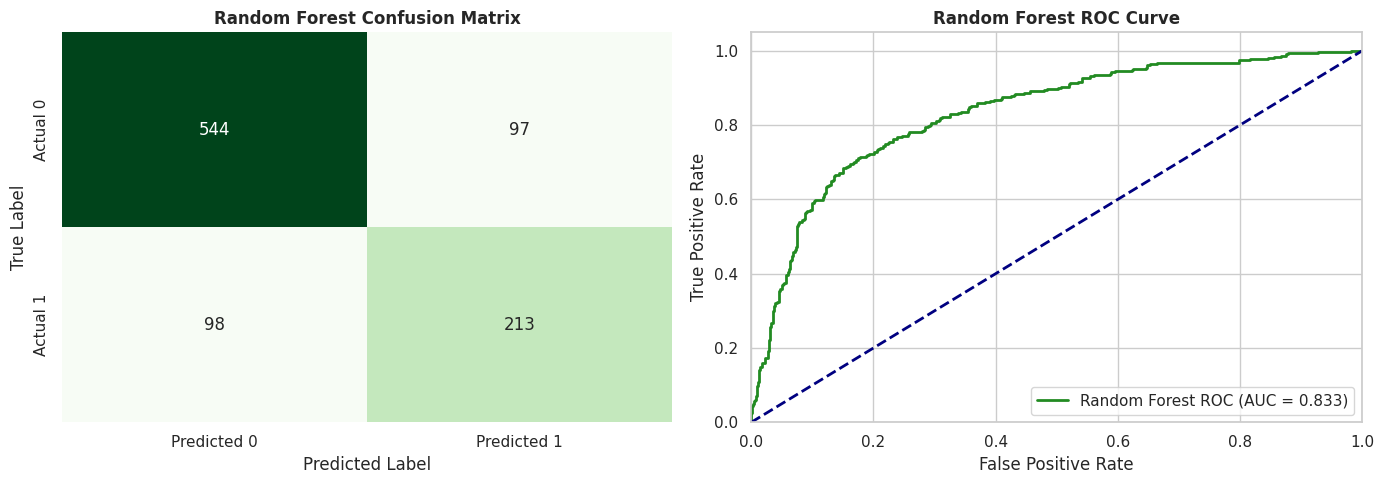


💾 Evaluation charts saved directly to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_random_forest_evaluation.png


In [ ]:
# ==========================================
# 7. VISUALIZE AND SAVE CHARTS
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Random Forest Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, color='forestgreen', lw=2, label=f'Random Forest ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Random Forest ROC Curve', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()

# Save the evaluation dashboard to your shared drive folder
output_plot_path = file_path.replace('super_dataset_C_train.csv', 'team_random_forest_evaluation.png')
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Evaluation charts saved directly to your shared Drive folder at:\n   {output_plot_path}")

### Evaluating the Tuned Random Forest Model

In [ ]:
print("\n🚀 Step 9: Evaluating the Tuned Random Forest Model...")

# Generate predictions using the best model from RandomizedSearchCV
y_pred_tuned = best_rf.predict(X_val)
y_pred_proba_tuned = best_rf.predict_proba(X_val)[:, 1]

print("\n================ 📊 TUNED RANDOM FOREST EVALUATION REPORT ================ ")
auc_score_tuned = roc_auc_score(y_val, y_pred_proba_tuned)
print(f"▶️ Tuned Random Forest Validation ROC-AUC: {auc_score_tuned:.4f}\n")
print("▶️ Classification Performance Metrics:")
print(classification_report(y_val, y_pred_tuned, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))


🚀 Step 9: Evaluating the Tuned Random Forest Model...

================ 📊 TUNED RANDOM FOREST EVALUATION REPORT ================ 
▶️ Tuned Random Forest Validation ROC-AUC: 0.8363

▶️ Classification Performance Metrics:
                    precision    recall  f1-score   support

Not Vaccinated (0)       0.80      0.92      0.86       641
    Vaccinated (1)       0.76      0.53      0.63       311

          accuracy                           0.79       952
         macro avg       0.78      0.73      0.74       952
      weighted avg       0.79      0.79      0.78       952



### Visualizing the Tuned Random Forest Model's Performance

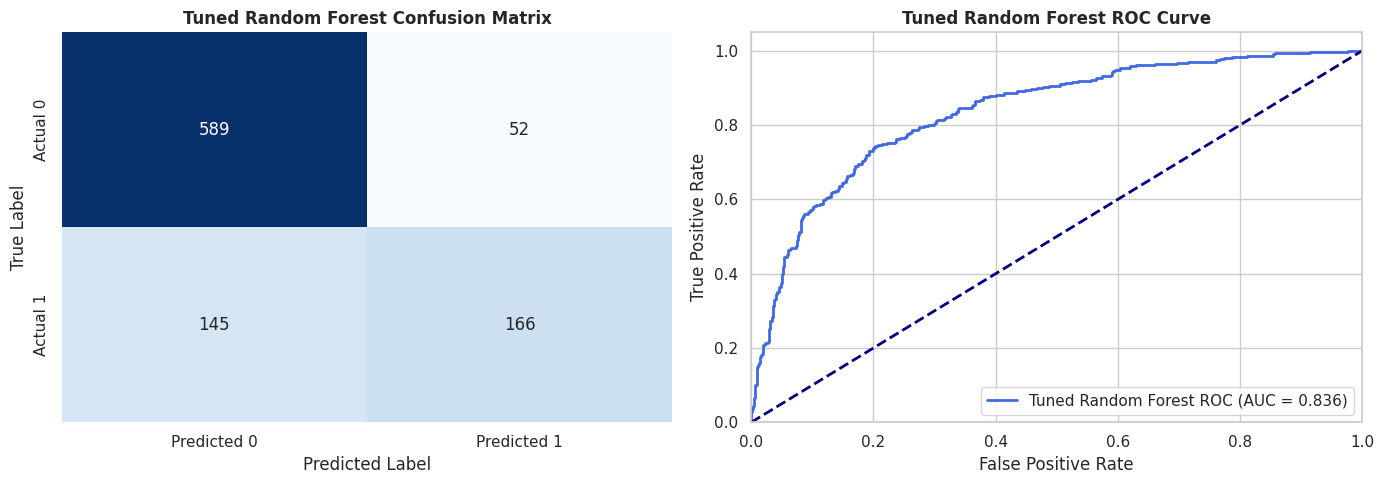


💾 Tuned evaluation charts saved directly to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_random_forest_evaluation_tuned.png


In [ ]:
sns.set_theme(style="whitegrid")
fig_tuned, axes_tuned = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap for Tuned Model
cm_tuned = confusion_matrix(y_val, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=axes_tuned[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_tuned[0].set_title('Tuned Random Forest Confusion Matrix', fontweight='bold')
axes_tuned[0].set_xlabel('Predicted Label')
axes_tuned[0].set_ylabel('True Label')

# ROC Curve for Tuned Model
fpr_tuned, tpr_tuned, _ = roc_curve(y_val, y_pred_proba_tuned)
axes_tuned[1].plot(fpr_tuned, tpr_tuned, color='royalblue', lw=2, label=f'Tuned Random Forest ROC (AUC = {auc_score_tuned:.3f})')
axes_tuned[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_tuned[1].set_xlim([0.0, 1.0])
axes_tuned[1].set_ylim([0.0, 1.05])
axes_tuned[1].set_xlabel('False Positive Rate')
axes_tuned[1].set_ylabel('True Positive Rate')
axes_tuned[1].set_title('Tuned Random Forest ROC Curve', fontweight='bold')
axes_tuned[1].legend(loc="lower right")

plt.tight_layout()

# Save the evaluation dashboard to your shared drive folder
output_plot_path_tuned = file_path.replace('super_dataset_C_train.csv', 'team_random_forest_evaluation_tuned.png')
plt.savefig(output_plot_path_tuned, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Tuned evaluation charts saved directly to your shared Drive folder at:\n   {output_plot_path_tuned}")

In [ ]:
# ==========================================================
# 9.2. LOAD AND PREPROCESS PRE-EXISTING TESTING DATA
# ==========================================================

print("\n⚙️ Step 9.2: Loading and preprocessing pre-existing testing data...")

# --- Configuration for Pre-existing Test Data ---
# Define the filename for your new test dataset.
# Adjust this to the actual name of your test CSV file.
# This assumes the test file is in the same base directory as your training data
SUPER_DATASET_TEST_FILENAME = 'super_dataset_C_test.csv' # <--- IMPORTANT: Change this to your test file name

# Ensure DRIVE_HACKATHON_BASE_PATH is defined (it should be if previous cells were run)
if 'DRIVE_HACKATHON_BASE_PATH' not in globals():
    raise RuntimeError("DRIVE_HACKATHON_BASE_PATH is not defined. Please run all cells from the beginning.")

# Construct the full path to the testing dataset
file_path_testing_dataset = DRIVE_HACKATHON_BASE_PATH / SUPER_DATASET_TEST_FILENAME

if file_path_testing_dataset.exists():
    df_testing_data = pd.read_csv(file_path_testing_dataset)
    print(f"🎯 SUCCESS! Loaded pre-existing testing dataset from: {file_path_testing_dataset}")
else:
    raise FileNotFoundError(f"❌ ERROR: Could not find '{SUPER_DATASET_TEST_FILENAME}' at {file_path_testing_dataset}. Please check the filename and path.")

# Clean column names for compatibility, just like the training data
df_testing_data.columns = [re.sub(r'[[\]<>]', '', col) for col in df_testing_data.columns]
print("🧼 Testing data column headers sanitized.")

# Identify features used for training (from X_model.columns)
# Ensure X_model is defined from previous steps
if 'X_model' not in globals():
    print("Warning: X_model not found. Re-creating from df_super for feature alignment. Please ensure df_super is loaded.")
    if 'df_super' not in globals():
        raise RuntimeError("df_super not found. Please run all cells from the beginning to define df_super and X_model.")
    X_model = df_super.drop(columns=['covid_vaccine'])

training_features_for_testing = X_model.columns.tolist()

# Handle 'respondent_id' if present in test data but not in training features
# This assumes 'respondent_id' is an identifier and not a feature for the model
if 'respondent_id' in df_testing_data.columns and 'respondent_id' not in training_features_for_testing:
    test_respondent_ids_testing = df_testing_data['respondent_id']
    df_testing_data = df_testing_data.drop(columns=['respondent_id'])
    print("Dropped 'respondent_id' from testing features as it was not in training features.")
elif 'respondent_id' not in df_testing_data.columns:
    test_respondent_ids_testing = pd.Series(df_testing_data.index, name='respondent_id') # Create dummy IDs if not present
    print("No 'respondent_id' found in testing data. Using DataFrame index as dummy IDs.")
else:
    test_respondent_ids_testing = df_testing_data['respondent_id']
    print("'respondent_id' found in testing data and also in training features. Keeping it.")

# Align test data columns with training data columns
# Add missing columns (fill with 0 or appropriate default)
missing_cols_testing = set(training_features_for_testing) - set(df_testing_data.columns)
for c in missing_cols_testing:
    df_testing_data[c] = 0  # Assuming 0 is an appropriate default for missing numerical features
    print(f"Added missing feature '{c}' to testing data with default value 0.")

# Drop extra columns not present in training features
extra_cols_testing = set(df_testing_data.columns) - set(training_features_for_testing)
for c in extra_cols_testing:
    df_testing_data = df_testing_data.drop(columns=[c])
    print(f"Dropped extra feature '{c}' from testing data.")

# Ensure the order of columns is the same as in training data
X_testing_processed = df_testing_data[training_features_for_testing]

print(f"Testing data prepared with {X_testing_processed.shape[0]} rows and {X_testing_processed.shape[1]} features.")
display(X_testing_processed.head())


⚙️ Step 9.2: Loading and preprocessing pre-existing testing data...
🎯 SUCCESS! Loaded pre-existing testing dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_test.csv
🧼 Testing data column headers sanitized.
Dropped 'respondent_id' from testing features as it was not in training features.
Testing data prepared with 4749 rows and 64 features.


/tmp/ipykernel_5271/1147008577.py:27: FutureWarning: Possible nested set at position 1
  df_testing_data.columns = [re.sub(r'[[\]<>]', '', col) for col in df_testing_data.columns]


,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,...,employment_sector_media,employment_sector_mining,employment_sector_real_estate,employment_sector_retail,employment_sector_science,employment_sector_services,employment_sector_technology,employment_sector_transportation,employment_sector_utilities,employment_sector_wholesale
0,-0.755939,-0.450851,-0.236088,0.610064,-0.296333,0.441554,-0.759835,-0.723522,-1.494767,-0.656790,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
1,-1.850770,-2.052025,-0.236088,-1.651602,-0.296333,0.441554,-0.759835,-0.723522,-1.494767,-0.214678,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
2,-0.755939,-0.450851,-0.236088,0.610064,-0.296333,0.441554,-0.759835,-0.723522,-1.494767,-0.656790,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
3,1.433724,-0.450851,-0.236088,0.610064,-0.296333,0.441554,1.321646,-0.723522,-1.494767,1.553766,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
4,-0.755939,-0.450851,-0.236088,-1.651602,-0.296333,-2.266969,-0.759835,-0.723522,-1.494767,-0.656790,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,4.732239


In [ ]:
# ==========================================================
# 10.2. MAKE PREDICTIONS ON PRE-EXISTING TESTING DATA
# ==========================================================

print("\n🔮 Step 10.2: Generating predictions on the pre-existing testing data...")

# Ensure best_rf model is available
if 'best_rf' not in globals():
    raise RuntimeError("best_rf model not found. Please ensure previous model training and tuning cells were run.")

# Make predictions using the best tuned model
predictions_testing_proba = best_rf.predict_proba(X_testing_processed)[:, 1] # Probability of being Vaccinated (class 1)
predictions_testing_class = best_rf.predict(X_testing_processed) # Predicted class (0 or 1)

# Create a DataFrame for the predictions
predictions_df_testing = pd.DataFrame({
    'respondent_id': test_respondent_ids_testing, # Use actual or dummy respondent IDs from testing data
    'predicted_covid_vaccine_proba': predictions_testing_proba,
    'predicted_covid_vaccine_class': predictions_testing_class
})

print("✅ Predictions generated successfully for testing data.")
display(predictions_df_testing.head())

# Optional: Save predictions to Google Drive
output_predictions_path_testing = DRIVE_HACKATHON_BASE_PATH / 'testing_data_predictions_rf.csv'
predictions_df_testing.to_csv(output_predictions_path_testing, index=False)
print(f"\n💾 Predictions for testing data saved to: {output_predictions_path_testing}")


🔮 Step 10.2: Generating predictions on the pre-existing testing data...
✅ Predictions generated successfully for testing data.


,respondent_id,predicted_covid_vaccine_proba,predicted_covid_vaccine_class
0,4757,0.190413,0
1,4758,0.173489,0
2,4759,0.203013,0
3,4760,0.311837,0
4,4761,0.089937,0



💾 Predictions for testing data saved to: /content/drive/MyDrive/Hackathon_05 06/testing_data_predictions_rf.csv
